# Qini and AUUC evaluation



In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import compute_qini_auuc, get_qini_curve, get_cumulative_gain_curve
from src.plotting import save_fig, plot_qini_curve, plot_cumulative_gain_curve
from src.config import PREDICTIONS_DIR, MODEL_RESULTS_DIR, PROCESSED_DATA_DIR, FIGURES_DIR

print("Project root:", PROJECT_ROOT)
print("Predictions dir:", PREDICTIONS_DIR)
print("Model results dir:", MODEL_RESULTS_DIR)

Project root: /Users/beza/hillstrom-email-uplift-modeling
Predictions dir: /Users/beza/hillstrom-email-uplift-modeling/outputs/predictions
Model results dir: /Users/beza/hillstrom-email-uplift-modeling/outputs/model_results


## Load Predictions and Canonical Test Set

Load each model's saved predictions from `outputs/predictions/`, along with the canonical held-out `y_test` and `treatment_test` arrays. For models whose prediction files include their own `y_true` column (Response Baseline, S-Learner, T-Learner, Causal Forest), we verify it matches the canonical `y_test` row-for-row to confirm consistent ordering across all prediction files before combining them into a single evaluation frame.

In [2]:
rb_preds = pd.read_csv(PREDICTIONS_DIR / 'response_baseline_predictions.csv')
s_preds = pd.read_csv(PREDICTIONS_DIR / 's_learner_predictions.csv')
t_preds = pd.read_csv(PREDICTIONS_DIR / 't_learner_predictions.csv')
x_preds = pd.read_csv(PREDICTIONS_DIR / 'tau_hat_x.csv')
r_preds = pd.read_csv(PREDICTIONS_DIR / 'tau_hat_r.csv')
cf_preds = pd.read_csv(PREDICTIONS_DIR / 'causal_forest_predictions.csv')

treatment_test = pd.read_csv(PROCESSED_DATA_DIR / 'treatment_test.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DATA_DIR / 'y_test.csv').squeeze()

for name, df in [('rb_preds', rb_preds), ('s_preds', s_preds), ('t_preds', t_preds),
                  ('x_preds', x_preds), ('r_preds', r_preds), ('cf_preds', cf_preds)]:
    print(f"{name}: {df.shape} {df.columns.tolist()}")

print("\ntreatment_test:", treatment_test.shape)
print("y_test:", y_test.shape)

for name, df in [('RB', rb_preds), ('S-Learner', s_preds), ('T-Learner', t_preds), ('CF', cf_preds)]:
    if 'y_true' in df.columns:
        print(f"{name} y_true matches canonical y_test:", (df['y_true'].values == y_test.values).all())

rb_preds: (16000, 5) ['y_true', 'logistic_proba', 'logistic_pred', 'xgboost_proba', 'xgboost_pred']
s_preds: (16000, 4) ['y_true', 'treatment', 'tau_hat_lr', 'tau_hat_xgb']
t_preds: (16000, 12) ['y_true', 'treatment', 'segment', 'lgr_pred_visit_if_treated', 'lgr_pred_visit_if_control', 'lgr_predicted_uplift', 'xgb_pred_visit_if_treated', 'xgb_pred_visit_if_control', 'xgb_predicted_uplift', 'rf_pred_visit_if_treated', 'rf_pred_visit_if_control', 'rf_predicted_uplift']
x_preds: (16000, 2) ['index', 'tau_hat_x']
r_preds: (16000, 2) ['index', 'tau_hat_r']
cf_preds: (16000, 4) ['y_true', 'treatment', 'segment', 'cf_predicted_uplift']

treatment_test: (16000,)
y_test: (16000,)
RB y_true matches canonical y_test: True
S-Learner y_true matches canonical y_test: True
T-Learner y_true matches canonical y_test: True
CF y_true matches canonical y_test: True


## Build the Uplift Score Dictionary

Collect each model's predicted uplift into a single dictionary, keyed by model/base-learner name. T-Learner, S-Learner, and Response Baseline each contribute multiple entries (one per base learner), while X-Learner, R-Learner, and Causal Forest each contribute one. All ten arrays are aligned to the same canonical `y_test`/`treatment_test` ordering, since `causalml`'s scoring functions require every model to be evaluated against a single shared outcome and treatment vector rather than per-model copies.

In [3]:
tau_hat_dict = {
    "Response Baseline (LR)": rb_preds['logistic_proba'].values,
    "Response Baseline (XGB)": rb_preds['xgboost_proba'].values,

    "S-Learner (LR)": s_preds['tau_hat_lr'].values,
    "S-Learner (XGB)": s_preds['tau_hat_xgb'].values,

    "T-Learner (LR)": t_preds['lgr_predicted_uplift'].values,
    "T-Learner (XGB)": t_preds['xgb_predicted_uplift'].values,
    "T-Learner (RF)": t_preds['rf_predicted_uplift'].values,

    "X-Learner": x_preds['tau_hat_x'].values,
    "R-Learner": r_preds['tau_hat_r'].values,
    "Causal Forest": cf_preds['cf_predicted_uplift'].values,
}

for name, arr in tau_hat_dict.items():
    print(f"{name}: n={len(arr)}, mean={arr.mean():.4f}, min={arr.min():.4f}, max={arr.max():.4f}")

Response Baseline (LR): n=16000, mean=0.1465, min=0.0522, max=0.4672
Response Baseline (XGB): n=16000, mean=0.1462, min=0.0212, max=0.5655
S-Learner (LR): n=16000, mean=0.0596, min=0.0238, max=0.1291
S-Learner (XGB): n=16000, mean=0.0589, min=-0.1974, max=0.3737
T-Learner (LR): n=16000, mean=0.0598, min=-0.0385, max=0.1215
T-Learner (XGB): n=16000, mean=0.0602, min=-0.0849, max=0.1989
T-Learner (RF): n=16000, mean=0.0599, min=-0.0293, max=0.1625
X-Learner: n=16000, mean=0.0596, min=-0.0284, max=0.1368
R-Learner: n=16000, mean=0.0602, min=-0.1290, max=0.2687
Causal Forest: n=16000, mean=0.0608, min=-0.1647, max=0.2861


## Compute Qini and AUUC Scores

Score all ten models in a single call to `compute_qini_auuc`, which builds one shared `{y, w, model1, model2, ...}` DataFrame internally and scores every column against `causalml`'s Qini and AUUC metrics with `normalize=True`. Using one function call across all models guarantees every score in this comparison is computed identically.

In [4]:
scores = compute_qini_auuc(y_test.values, treatment_test.values, tau_hat_dict, normalize=True)

qini_scores = scores["qini_score"]
auuc_scores = scores["auuc_score"]

print("Qini scores:")
print(qini_scores.sort_values(ascending=False))

print("\nAUUC scores:")
print(auuc_scores.sort_values(ascending=False))

Qini scores:
T-Learner (LR)             0.089026
Response Baseline (LR)     0.069812
S-Learner (LR)             0.069450
Response Baseline (XGB)    0.064403
X-Learner                  0.049960
R-Learner                  0.045847
T-Learner (RF)             0.044387
T-Learner (XGB)            0.044275
S-Learner (XGB)            0.038737
Causal Forest              0.006526
dtype: float64

AUUC scores:
T-Learner (LR)             0.591944
Response Baseline (LR)     0.573460
S-Learner (LR)             0.573155
Response Baseline (XGB)    0.567698
X-Learner                  0.551028
R-Learner                  0.547161
T-Learner (RF)             0.545956
T-Learner (XGB)            0.545802
S-Learner (XGB)            0.541095
Causal Forest              0.507891
dtype: float64


## Model Comparison Table

Assemble the Qini and AUUC scores for all ten model/base-learner combinations into a single ranked table, sorted by Qini score in descending order. This table is the authoritative source for the model comparison, all scores come from the same `compute_qini_auuc` call above rather than from each model's individually saved results file, so the ranking here should be treated as canonical over any numbers recorded elsewhere in `outputs/model_results/`.

In [5]:
rows = []
for name in tau_hat_dict:
    rows.append({
        'Model': name,
        'Qini Score': qini_scores[name],
        'AUUC Score': auuc_scores[name],
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values('Qini Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,Qini Score,AUUC Score
0,T-Learner (LR),0.089026,0.591944
1,Response Baseline (LR),0.069812,0.573460
2,S-Learner (LR),0.069450,0.573155
3,Response Baseline (XGB),0.064403,0.567698
4,X-Learner,0.049960,0.551028
5,R-Learner,0.045847,0.547161
6,T-Learner (RF),0.044387,0.545956
7,T-Learner (XGB),0.044275,0.545802
8,S-Learner (XGB),0.038737,0.541095
9,Causal Forest,0.006526,0.507891


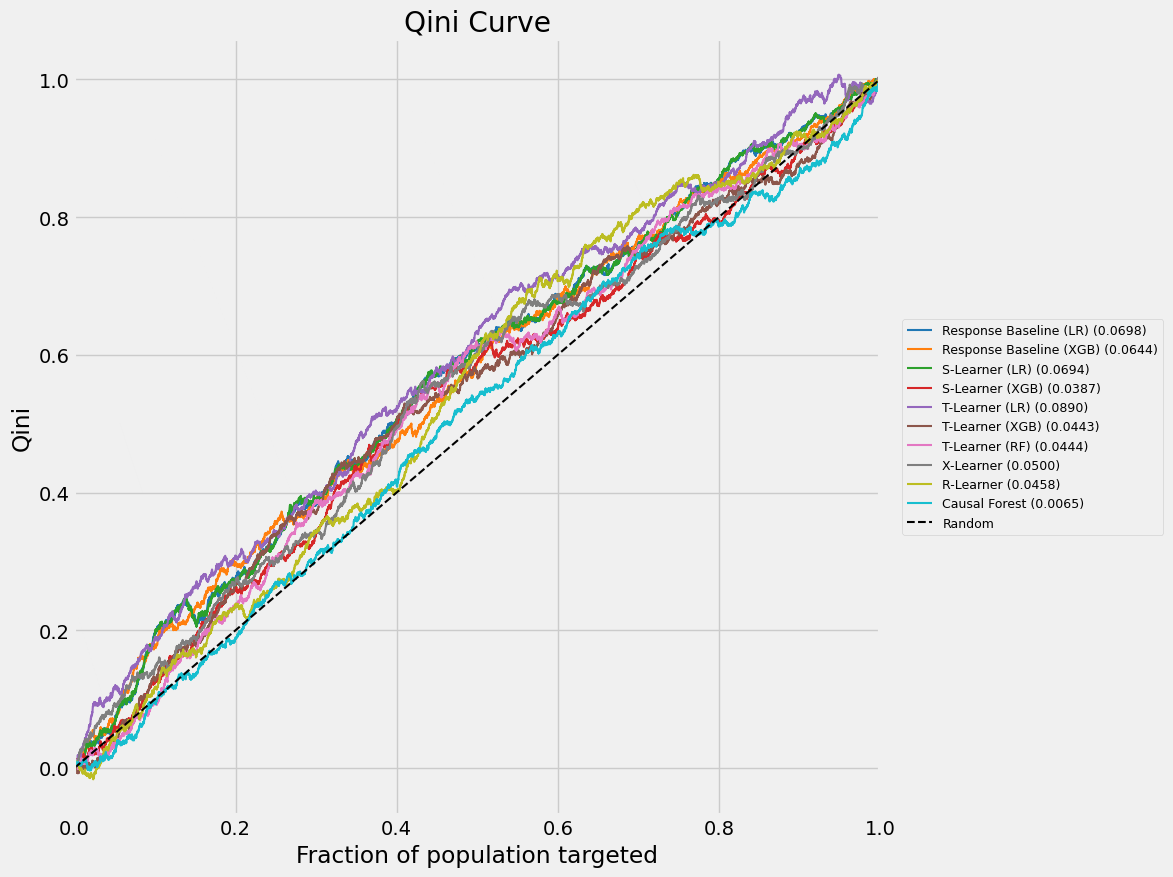

PosixPath('/Users/beza/hillstrom-email-uplift-modeling/outputs/figures/model_comparison_qini_curves_causalml.png')

In [6]:
fig_qini = plot_qini_curve(y_test.values, treatment_test.values, tau_hat_dict, figsize=(12, 9))
save_fig(fig_qini, "model_comparison_qini_curves_causalml.png")

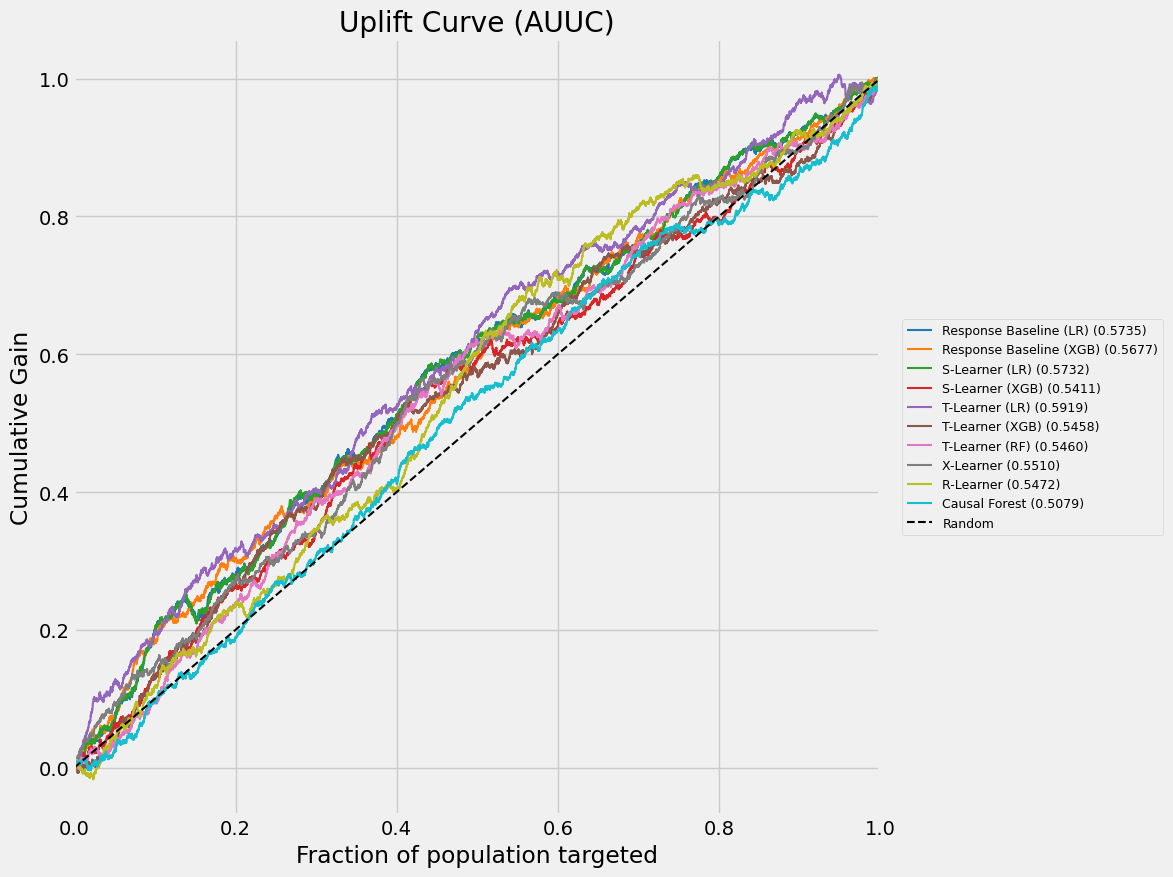

PosixPath('/Users/beza/hillstrom-email-uplift-modeling/outputs/figures/model_comparison_auuc_curves_causalml.png')

In [7]:

fig_gain = plot_cumulative_gain_curve(y_test.values, treatment_test.values, tau_hat_dict, figsize=(12, 9))
save_fig(fig_gain, "model_comparison_auuc_curves_causalml.png")

In [8]:
model_families = {
    "Response Baseline": ["Response Baseline (LR)", "Response Baseline (XGB)"],
    "S-Learner": ["S-Learner (LR)", "S-Learner (XGB)"],
    "T-Learner": ["T-Learner (LR)", "T-Learner (XGB)", "T-Learner (RF)"],
}

tau_hat_dict_trimmed = {}
for family, variants in model_families.items():
    best_variant = qini_scores[variants].idxmax()
    tau_hat_dict_trimmed[best_variant] = tau_hat_dict[best_variant]

for name in ["X-Learner", "R-Learner", "Causal Forest"]:
    tau_hat_dict_trimmed[name] = tau_hat_dict[name]

print("Trimmed to", len(tau_hat_dict_trimmed), "models:")
for name in tau_hat_dict_trimmed:
    print(" -", name)

Trimmed to 6 models:
 - Response Baseline (LR)
 - S-Learner (LR)
 - T-Learner (LR)
 - X-Learner
 - R-Learner
 - Causal Forest


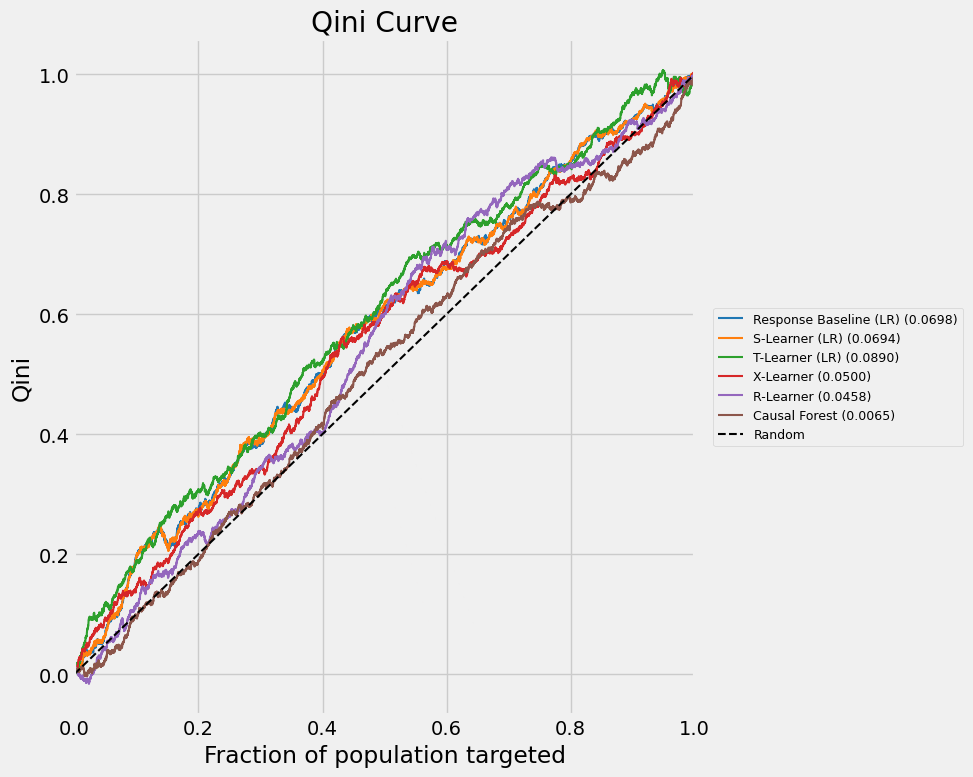

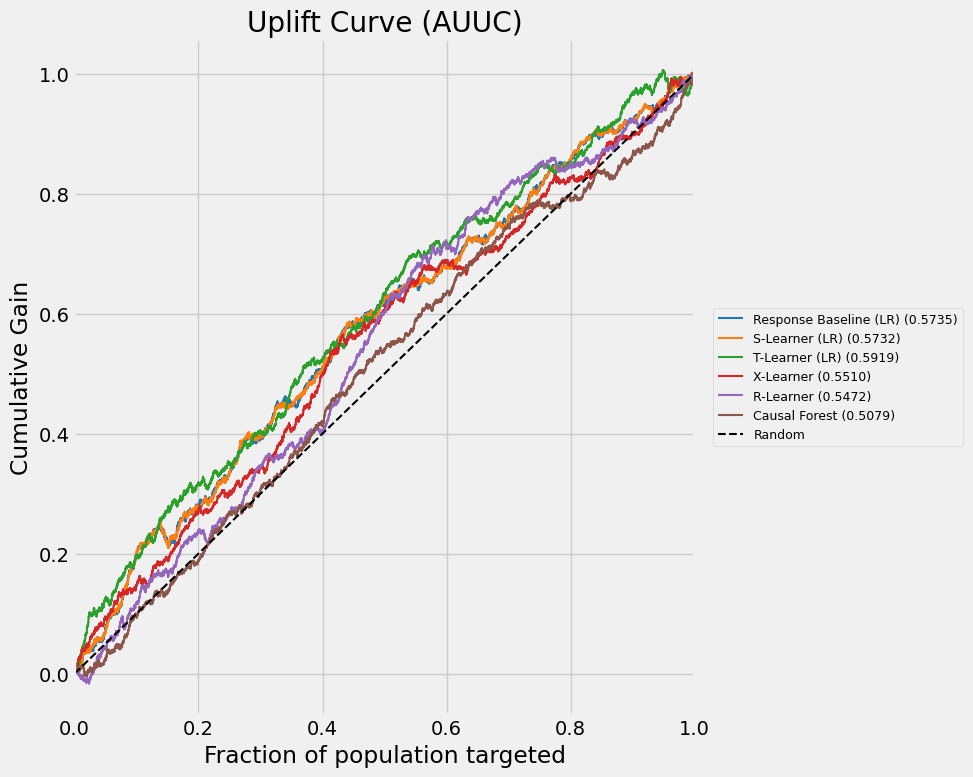

PosixPath('/Users/beza/hillstrom-email-uplift-modeling/outputs/figures/model_comparison_auuc_curves_causalml.png')

In [9]:
fig_qini = plot_qini_curve(y_test.values, treatment_test.values, tau_hat_dict_trimmed, figsize=(10, 8))
save_fig(fig_qini, "model_comparison_qini_curves_causalml.png")

fig_gain = plot_cumulative_gain_curve(y_test.values, treatment_test.values, tau_hat_dict_trimmed, figsize=(10, 8))
save_fig(fig_gain, "model_comparison_auuc_curves_causalml.png")

## Model Comparison Results

All ten model/base-learner combinations were scored with a single consistent method, `causalml`'s `qini_score` and `auuc_score`, computed once across a shared evaluation frame (Block 4),  so every number in this comparison and in Table 2 is directly comparable.

The T-Learner with a logistic regression base learner achieved the highest performance by a clear margin, with a Qini score of 0.0890 and an AUUC of 0.5919. The naive Response Baseline (LR) and S-Learner (LR) followed closely behind, at 0.0698 and 0.0695 respectively, both ahead of the X-Learner (0.0500) and the newly added R-Learner (0.0458). The T-Learner's random forest and XGBoost variants scored lower still, at 0.0444 and 0.0443, essentially tied with one another and only narrowly ahead of R-Learner. S-Learner (XGB) trailed further at 0.0387.

The Causal Forest scored lowest by a substantial margin, with a Qini of 0.0065 and an AUUC of 0.5079, noticeably closer to the random-targeting baseline than any other model.